## Task1 Data Exploration

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
df = pd.read_csv("network_traffic.csv")

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(6000, 16)


In [89]:
df.head()

,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
0,0,244,3252,0,0,1,0,16,16,0.0,1.00,0.00,34,255,1.00,0
1,0,8,0,0,0,0,0,1,21,0.0,1.00,0.00,1,41,1.00,1
2,0,242,5278,0,0,1,0,6,11,0.0,1.00,0.00,255,255,1.00,0
3,0,45,76,0,0,0,0,161,161,0.0,1.00,0.00,255,203,0.80,0
4,0,1,0,0,0,0,0,13,2,0.0,0.15,0.15,255,29,0.11,1


In [90]:
df.describe()

,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
count,6000.000000,6.000000e+03,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,413.933000,1.603307e+04,2.951740e+03,0.028333,0.206167,0.385000,0.179667,80.434500,27.572333,0.293578,0.658218,0.060692,180.643333,112.433000,0.519193,0.500000
std,3237.030266,3.049754e+05,7.057366e+04,0.283803,2.120632,0.486636,8.981360,108.869318,70.945265,0.451700,0.438878,0.170613,99.879900,108.894863,0.445222,0.500042
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.100000,0.000000,79.000000,11.000000,0.050000,0.000000
50%,0.000000,4.300000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,15.000000,8.000000,0.000000,1.000000,0.000000,255.000000,60.000000,0.490000,0.500000
75%,0.000000,2.730000e+02,4.550000e+02,0.000000,0.000000,1.000000,0.000000,135.250000,18.000000,1.000000,1.000000,0.060000,255.000000,255.000000,1.000000,1.000000
max,42569.000000,1.698050e+07,5.149533e+06,3.000000,30.000000,1.000000,520.000000,511.000000,511.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000


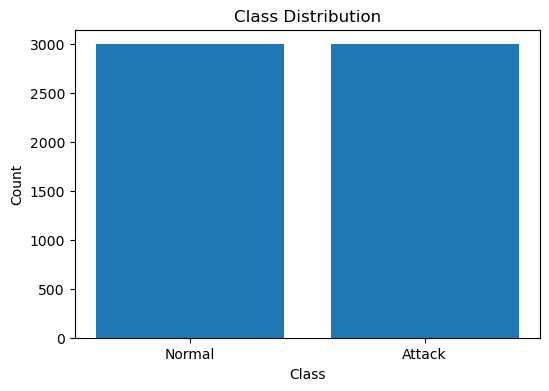

In [91]:
class_counts = df["label"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(["Normal", "Attack"],class_counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [92]:
normal = df[df["label"] == 0]
attack = df[df["label"] == 1]

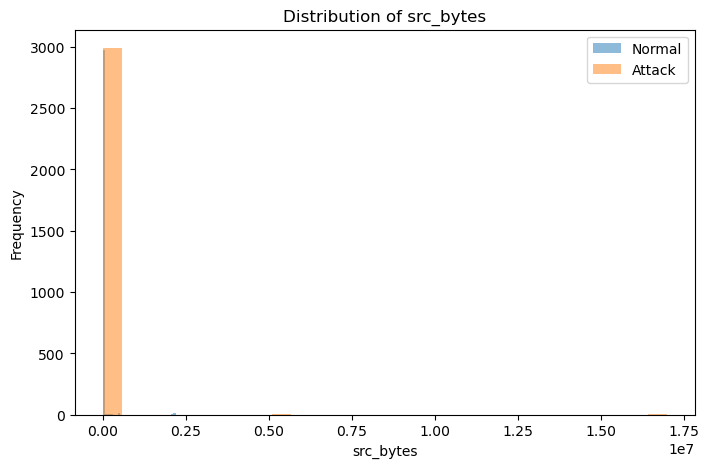

In [93]:
plt.figure(figsize=(8,5))

plt.hist(normal["src_bytes"],
         bins=30,
         alpha=0.5,
         label="Normal")

plt.hist(attack["src_bytes"],
         bins=30,
         alpha=0.5,
         label="Attack")

plt.title("Distribution of src_bytes")
plt.xlabel("src_bytes")
plt.ylabel("Frequency")

plt.legend()
plt.show()

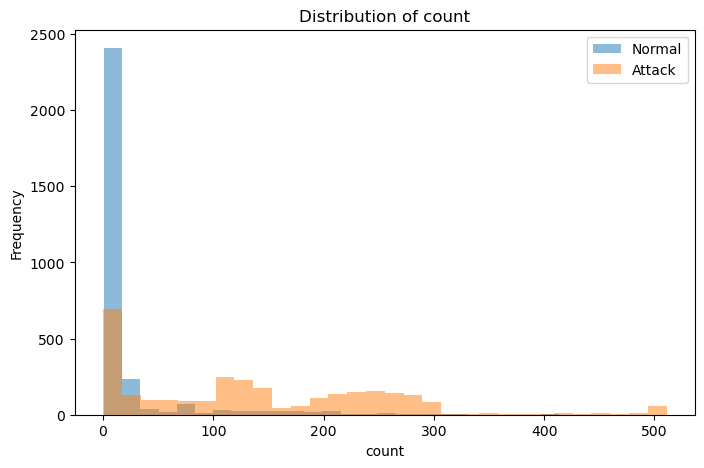

In [94]:
plt.figure(figsize=(8,5))

plt.hist(normal["count"], bins=30, alpha=0.5, label="Normal")

plt.hist(attack["count"],  bins=30,  alpha=0.5,  label="Attack")

plt.title("Distribution of count")
plt.xlabel("count")
plt.ylabel("Frequency")

plt.legend()

plt.show()

## Task 2  Simple Reflex Agent

In [95]:
def reflex_agent(row):

    if row["serror_rate"] > 0.5:
        return 1

    elif row["count"] > 100:
        return 1

    elif row["same_srv_rate"] < 0.4:
        return 1

    else:
        return 0

In [96]:
predictions = df.apply(reflex_agent, axis=1)

predictions.head()

0    0
1    0
2    0
3    1
4    1
dtype: int64

In [97]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(  df["label"], predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8415


In [98]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix( df["label"],  predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2710  290]
 [ 661 2339]]


## Task 3  Supervised Learning

In [99]:
X = df.drop("label", axis=1)
y = df["label"]

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (6000, 15)
Labels Shape: (6000,)


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X,y,  test_size=0.2,random_state=42, stratify=y)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4800
Testing Samples: 1200


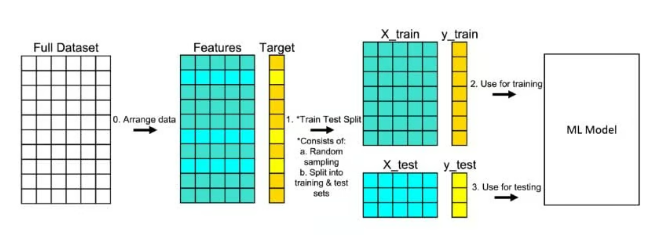

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## KNN Classifier

In [102]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    accuracies.append(acc)

    print(f"K = {k}, Accuracy = {acc:.4f}")

K = 1, Accuracy = 0.9575
K = 3, Accuracy = 0.9575
K = 5, Accuracy = 0.9558
K = 7, Accuracy = 0.9533
K = 9, Accuracy = 0.9517
K = 11, Accuracy = 0.9475


In [103]:
best_k = 1

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [104]:
knn_accuracy = accuracy_score(y_test, knn_pred)

knn_precision = precision_score(y_test, knn_pred)

knn_recall = recall_score(y_test, knn_pred)

knn_f1 = f1_score(y_test, knn_pred)

knn_cm = confusion_matrix(y_test, knn_pred)

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

print("\nConfusion Matrix")
print(knn_cm)

Accuracy : 0.9575
Precision: 0.9492635024549918
Recall   : 0.9666666666666667
F1 Score : 0.9578860445912469

Confusion Matrix
[[569  31]
 [ 20 580]]


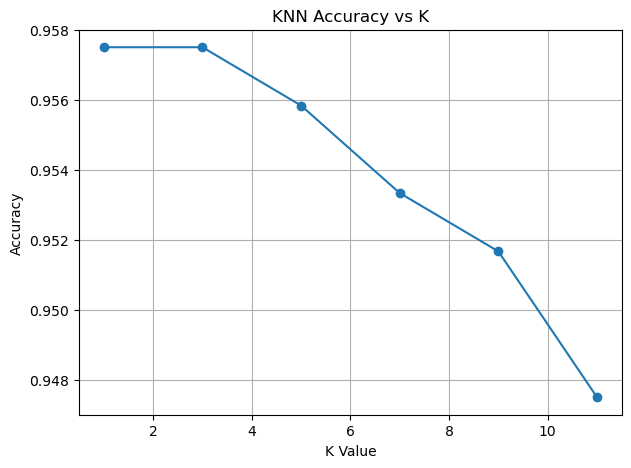

In [105]:
plt.figure(figsize=(7,5))

plt.plot(k_values, accuracies, marker='o')

plt.title("KNN Accuracy vs K")
plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

## Gaussian Naive Bayes

In [106]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [107]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(y_test, nb_pred)

nb_recall = recall_score(y_test, nb_pred)

nb_f1 = f1_score(y_test, nb_pred)

nb_cm = confusion_matrix(y_test, nb_pred)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

print("\nConfusion Matrix")
print(nb_cm)

Accuracy : 0.7875
Precision: 0.9367088607594937
Recall   : 0.6166666666666667
F1 Score : 0.7437185929648241

Confusion Matrix
[[575  25]
 [230 370]]


## Logistic Regression

In [108]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression( max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [109]:
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(y_test, lr_pred)

lr_recall = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)



lr_cm = confusion_matrix(y_test, lr_pred)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

print("\nConfusion Matrix")
print(lr_cm)

Accuracy : 0.915
Precision: 0.9249146757679181
Recall   : 0.9033333333333333
F1 Score : 0.9139966273187183

Confusion Matrix
[[556  44]
 [ 58 542]]


In [110]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy": [
        knn_accuracy,
        nb_accuracy,
        lr_accuracy
    ],

    "Precision": [
        knn_precision,
        nb_precision,
        lr_precision
    ],

    "Recall": [
        knn_recall,
        nb_recall,
        lr_recall
    ],

    "F1 Score": [
        knn_f1,
        nb_f1,
        lr_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.9575,0.949264,0.966667,0.957886
1,Naive Bayes,0.7875,0.936709,0.616667,0.743719
2,Logistic Regression,0.9150,0.924915,0.903333,0.913997


## TASK 4  K-Means Clustering

In [111]:
X_cluster = df.drop("label", axis=1)

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

In [113]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print(clusters[:10])

[0 0 0 0 1 0 0 0 0 0]


In [114]:
from sklearn import metrics

cm = metrics.confusion_matrix(
    df["label"],
    clusters
)

print(cm)

[[2847  153]
 [ 627 2373]]


In [115]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

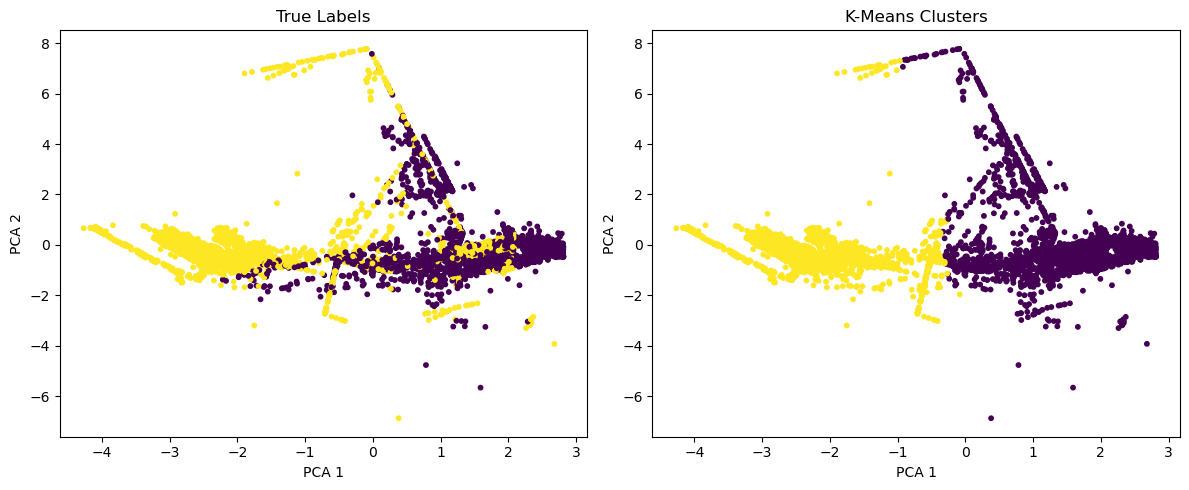

In [116]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["label"],
    s=10
)

plt.title("True Labels")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")


plt.subplot(1,2,2)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    s=10
)

plt.title("K-Means Clusters")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()

plt.show()

## Task 5 Genetic Algorithm

In [117]:
feature_names = X.columns.tolist()

print(feature_names)

['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised', 'count', 'srv_count', 'serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate']


In [118]:
population_size = 10
num_features = 15

population = []

for i in range(population_size):

    chromosome = np.random.randint( 0, 2, num_features )

    population.append(chromosome)

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

def fitness(chromosome):

    selected = []

    for i in range(len(chromosome)):

        if chromosome[i] == 1:
            selected.append(i)

    if len(selected) == 0:
        return 0

    X_train_sub = X_train.iloc[:, selected]
    X_test_sub = X_test.iloc[:, selected]

    scaler = StandardScaler()

    X_train_sub = scaler.fit_transform(X_train_sub)
    X_test_sub = scaler.transform(X_test_sub)

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train_sub, y_train)

    pred = model.predict(X_test_sub)

    acc = metrics.accuracy_score(y_test,pred)

    return acc

In [120]:
generations = 10

best_chromosome = None
best_score = 0

In [121]:
for generation in range(generations):

    scores = []

    for chromosome in population:

        score = fitness(chromosome)

        scores.append(score)

        if score > best_score:

            best_score = score
            best_chromosome = chromosome.copy()

    ranked = sorted( zip(scores, population), reverse=True, key=lambda x: x[0])

    parent1 = ranked[0][1]
    parent2 = ranked[1][1]

    new_population = []

    while len(new_population) < population_size:

        point = np.random.randint(
            1,
            num_features
        )

        child = np.concatenate(
            (
                parent1[:point],
                parent2[point:]
            )
        )

        for i in range(num_features):

            if np.random.rand() < 0.05:

                child[i] = 1 - child[i]

        new_population.append(child)

    population = new_population

    print( "Generation", generation + 1, "Best Accuracy:", round(best_score, 4))

Generation 1 Best Accuracy: 0.8842
Generation 2 Best Accuracy: 0.8875
Generation 3 Best Accuracy: 0.8875
Generation 4 Best Accuracy: 0.8875
Generation 5 Best Accuracy: 0.8875
Generation 6 Best Accuracy: 0.8883
Generation 7 Best Accuracy: 0.8883
Generation 8 Best Accuracy: 0.895
Generation 9 Best Accuracy: 0.8992
Generation 10 Best Accuracy: 0.8992


In [122]:
selected_features = []

for i in range(num_features):

    if best_chromosome[i] == 1:

        selected_features.append(
            feature_names[i]
        )

print("Selected Features:")

for f in selected_features:
    print(f)

Selected Features:
src_bytes
wrong_fragment
hot
logged_in
num_compromised
count
srv_count
serror_rate
diff_srv_rate
dst_host_count
dst_host_srv_count


In [123]:
print("Best Chromosome:")
print(best_chromosome)

print()

print("Number of Features:",
      len(selected_features))

print()

print("Best Accuracy:",
      round(best_score, 4))

Best Chromosome:
[0 1 0 1 1 1 1 1 1 1 0 1 1 1 0]

Number of Features: 11

Best Accuracy: 0.8992


In [124]:
print("All Features Accuracy:",
      round(lr_accuracy, 4))

print("GA Accuracy:",
      round(best_score, 4))

All Features Accuracy: 0.915
GA Accuracy: 0.8992
